# All Metrics

Единый обзор уже рассчитанных метрик для classifier и detector веток:

- side by side quality leaderboard;
- side by side regression/correlation leaderboard по `drop`;
- сквозной leaderboard по всем найденным cache/table artifacts.

Классификационный leaderboard сортируется по `best_balanced_accuracy`. Для detector-артефактов в этом сравнении `best_balanced_accuracy` принудительно равен `best_accuracy`, потому что detector cache сбалансирован.

In [1]:
from pathlib import Path
import sys
import importlib

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "ClassifierDetectorExperiments":
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "ClassifierDetectorExperiments"))

import side_by_side_analysis as sbs
importlib.reload(sbs)

collect_all_metrics = sbs.collect_all_metrics
plot_metric_leaderboards = sbs.plot_metric_leaderboards
plot_quality_metric_triplets = sbs.plot_quality_metric_triplets
plot_correlation_metric_triplets = sbs.plot_correlation_metric_triplets
plot_side_by_side_metric_counts = sbs.plot_side_by_side_metric_counts
sanitize_quality_table = sbs.sanitize_quality_table
save_tables = sbs.save_tables


In [2]:
tables = collect_all_metrics(REPO_ROOT, force_rebuild=True)
roots = tables["roots"]
quality = sanitize_quality_table(tables["quality"].copy())
regression = tables["regression"].copy()
rows = tables["rows"].copy()

print("loaded from saved tables:", tables.get("loaded_from_saved_tables"))
print("quality rows:", quality.shape)
print("regression rows:", regression.shape)
print("source rows:", rows.shape)
print("output:", roots.comparison_output)
print("rows_quality:", int(quality["table"].astype(str).eq("rows_quality").sum()) if "table" in quality.columns else 0)
print("logit metrics:", int(quality["metric"].astype(str).isin(["clean_logit", "patched_logit"]).sum()) if "metric" in quality.columns else 0)
print("nan balanced accuracy:", int(quality["best_balanced_accuracy"].isna().sum()) if "best_balanced_accuracy" in quality.columns else 0)


loaded from saved tables: False
quality rows: (7632, 33)
regression rows: (767, 36)
source rows: (229119, 965)
output: /Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs
rows_quality: 0
logit metrics: 0
nan balanced accuracy: 0


In [3]:
cols = [c for c in [
    "source", "experiment", "metric", "family",
    "best_balanced_accuracy", "best_f1", "best_precision", "best_recall", "best_accuracy",
    "roc_auc", "best_threshold", "best_direction", "cache_file",
] if c in quality.columns]
display(quality[cols].head(50))

,source,experiment,metric,family,best_balanced_accuracy,best_f1,best_precision,best_recall,best_accuracy,roc_auc,best_threshold,best_direction,cache_file
0,classifier,spread_vs_precision,spread_delta_abs_mean,spread,0.688276,0.850070,0.744819,0.989963,0.743967,0.732230,0.062674,1,/Users/ashentide/PycharmProjects/PatchSuccessR...
1,classifier,spread_vs_precision,spread_delta_max,spread,0.684508,0.850203,0.752880,0.976424,0.747732,0.743566,0.505623,1,/Users/ashentide/PycharmProjects/PatchSuccessR...
2,classifier,spread_vs_precision,spread_delta_l2_rms,spread,0.681676,0.851214,0.748715,0.986228,0.747219,0.740262,0.126229,1,/Users/ashentide/PycharmProjects/PatchSuccessR...
3,classifier,psnr,psnr_top1_importance_sum,NaN,0.672146,0.848658,0.753944,0.970588,0.746192,0.703432,2010.182214,-1,/Users/ashentide/PycharmProjects/PatchSuccessR...
4,classifier,psnr,psnr_top1_importance_mean,NaN,0.672146,0.848658,0.753944,0.970588,0.746192,0.703432,8.008694,-1,/Users/ashentide/PycharmProjects/PatchSuccessR...
5,classifier,psnr,psnr_top2_importance_sum,NaN,0.669832,0.848320,0.745316,0.984360,0.741913,0.704257,4070.312059,-1,/Users/ashentide/PycharmProjects/PatchSuccessR...
6,classifier,psnr,psnr_top2_importance_mean,NaN,0.669832,0.848320,0.745316,0.984360,0.741913,0.704257,8.108191,-1,/Users/ashentide/PycharmProjects/PatchSuccessR...
7,classifier,psnr,psnr_top0p5_importance_sum,NaN,0.668476,0.849862,0.754297,0.973156,0.747903,0.698919,1040.912390,-1,/Users/ashentide/PycharmProjects/PatchSuccessR...
8,classifier,psnr,psnr_top0p5_importance_mean,NaN,0.668476,0.849862,0.754297,0.973156,0.747903,0.698919,8.327299,-1,/Users/ashentide/PycharmProjects/PatchSuccessR...
9,classifier,psnr,psnr_top10_importance_sum,NaN,0.659957,0.846889,0.743775,0.983193,0.739346,0.696502,22262.680796,-1,/Users/ashentide/PycharmProjects/PatchSuccessR...


In [4]:
cols = [c for c in [
    "source", "experiment", "metric", "n", "coverage",
    "pearson", "spearman", "abs_pearson", "abs_spearman", "main_score", "cache_file",
] if c in regression.columns]
display(regression[cols].head(50))

,source,experiment,metric,n,coverage,pearson,spearman,abs_pearson,abs_spearman,main_score,cache_file
0,classifier,spread_vs_precision,spread_delta_l2_rms,5843,1.0,0.520543,0.582729,0.520543,0.582729,0.582729,/Users/ashentide/PycharmProjects/PatchSuccessR...
1,classifier,spread_vs_precision,spread_delta_max,5843,1.0,0.523179,0.578696,0.523179,0.578696,0.578696,/Users/ashentide/PycharmProjects/PatchSuccessR...
2,classifier,spread_vs_precision,spread_delta_abs_mean,5843,1.0,0.455276,0.529228,0.455276,0.529228,0.529228,/Users/ashentide/PycharmProjects/PatchSuccessR...
3,classifier,psnr,psnr_top100_importance_min,5843,1.0,-0.443024,-0.477444,0.443024,0.477444,0.477444,/Users/ashentide/PycharmProjects/PatchSuccessR...
4,classifier,psnr,psnr_top50_importance_sum,5843,1.0,-0.366723,-0.417650,0.366723,0.417650,0.417650,/Users/ashentide/PycharmProjects/PatchSuccessR...
5,classifier,psnr,psnr_top50_importance_mean,5843,1.0,-0.366723,-0.417650,0.366723,0.417650,0.417650,/Users/ashentide/PycharmProjects/PatchSuccessR...
6,classifier,psnr,psnr_top25_importance_sum,5843,1.0,-0.363707,-0.416828,0.363707,0.416828,0.416828,/Users/ashentide/PycharmProjects/PatchSuccessR...
7,classifier,psnr,psnr_top25_importance_mean,5843,1.0,-0.363707,-0.416828,0.363707,0.416828,0.416828,/Users/ashentide/PycharmProjects/PatchSuccessR...
8,classifier,psnr,psnr_top2_importance_sum,5843,1.0,-0.363468,-0.415810,0.363468,0.415810,0.415810,/Users/ashentide/PycharmProjects/PatchSuccessR...
9,classifier,psnr,psnr_top2_importance_mean,5843,1.0,-0.363468,-0.415810,0.363468,0.415810,0.415810,/Users/ashentide/PycharmProjects/PatchSuccessR...


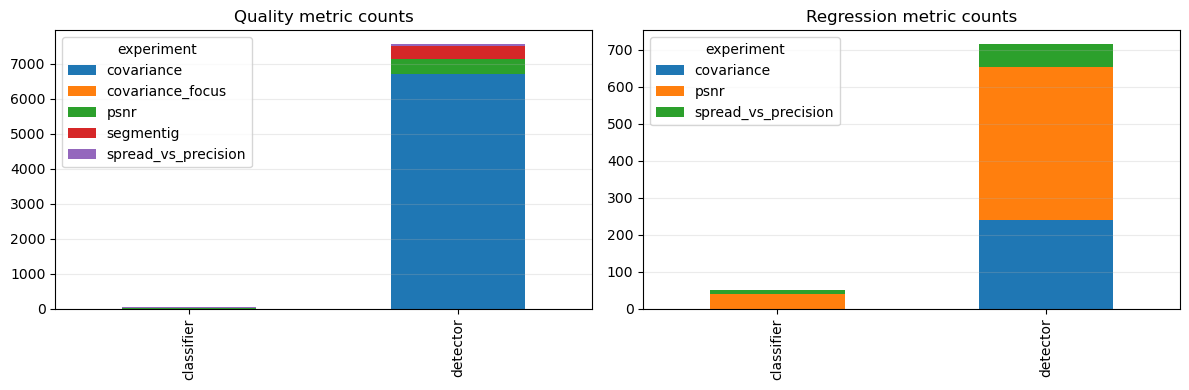

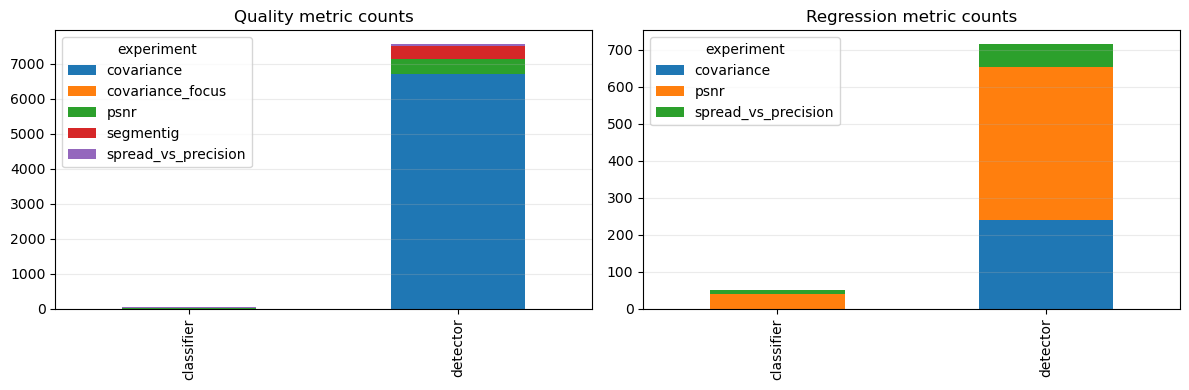

In [5]:
fig = plot_side_by_side_metric_counts(quality, regression)
fig.savefig(roots.comparison_output / "all_metrics_counts.png", dpi=160, bbox_inches="tight")
fig

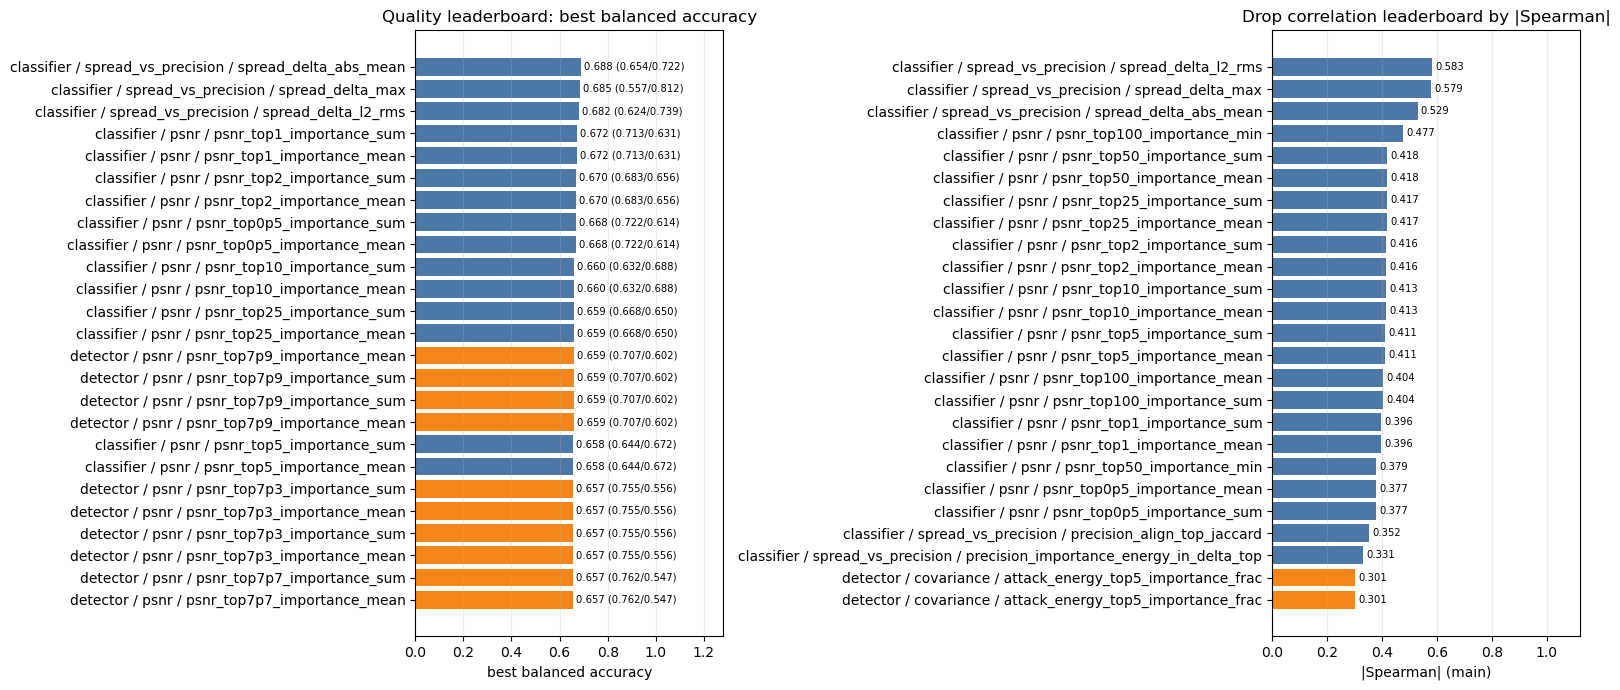

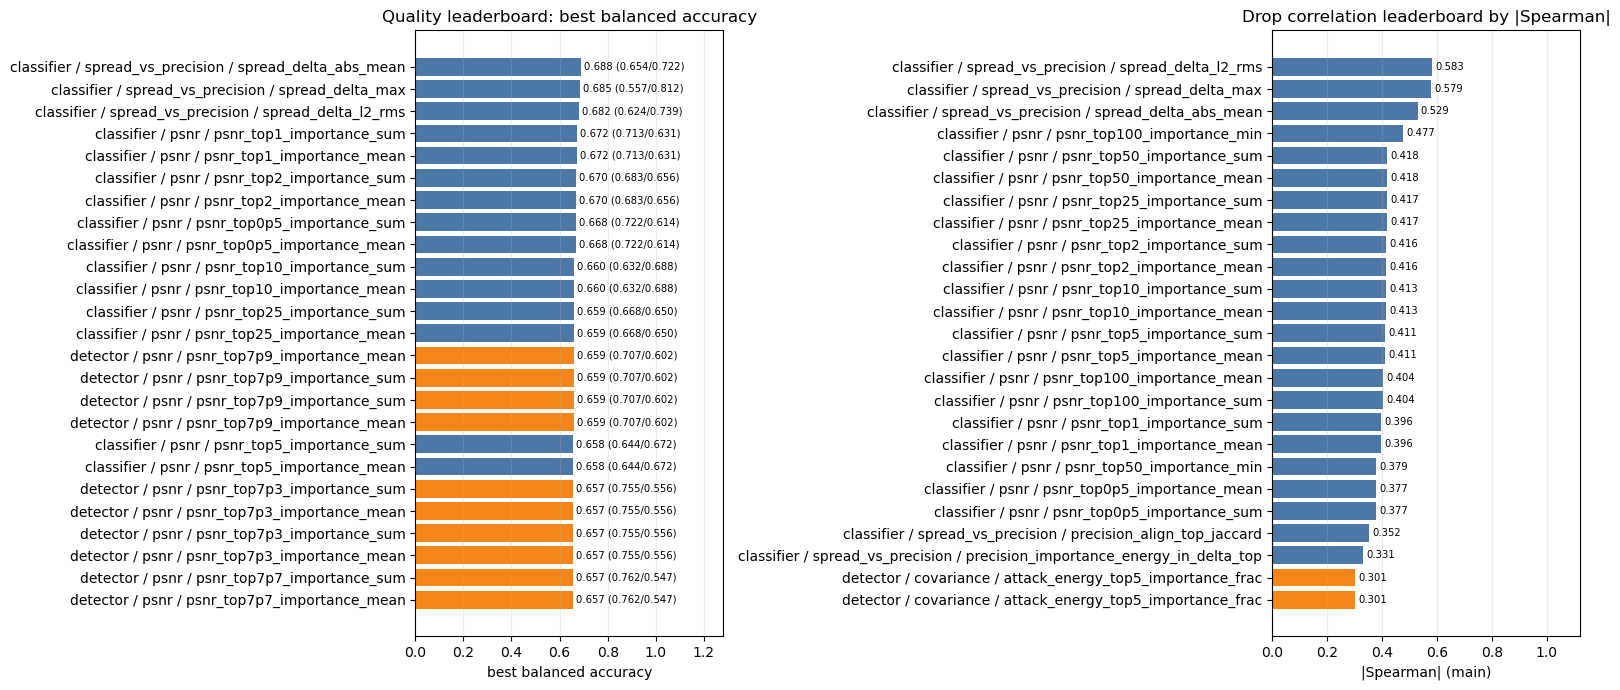

In [6]:
fig = plot_metric_leaderboards(quality, regression, top_n=25)
fig.savefig(roots.comparison_output / "all_metrics_leaderboards.png", dpi=160, bbox_inches="tight")
fig

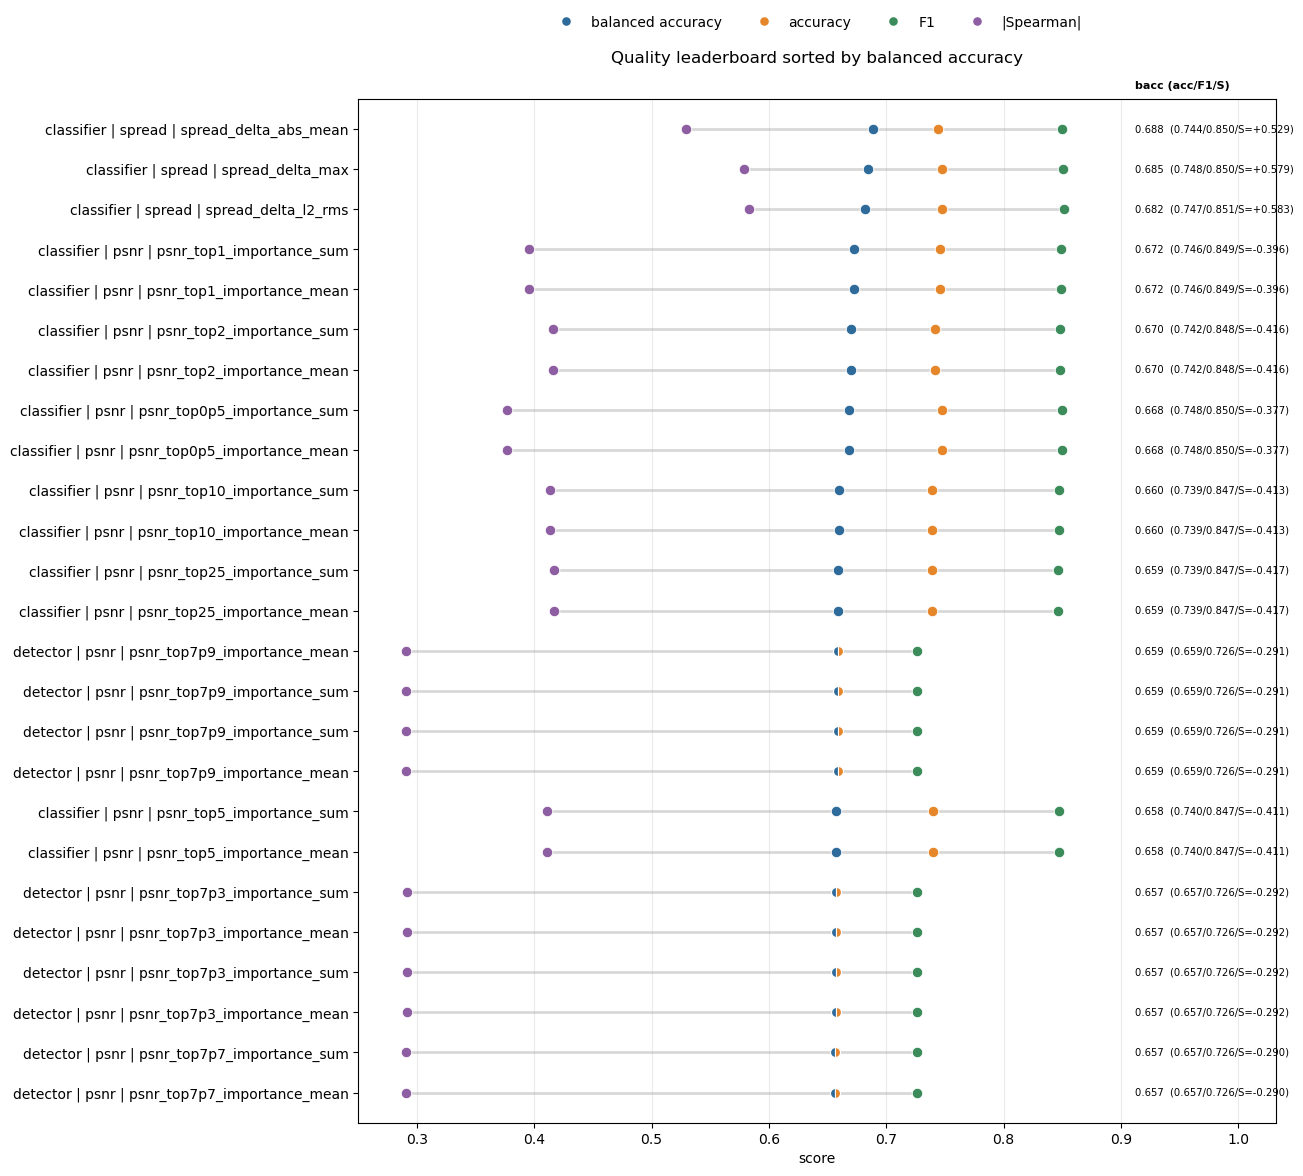

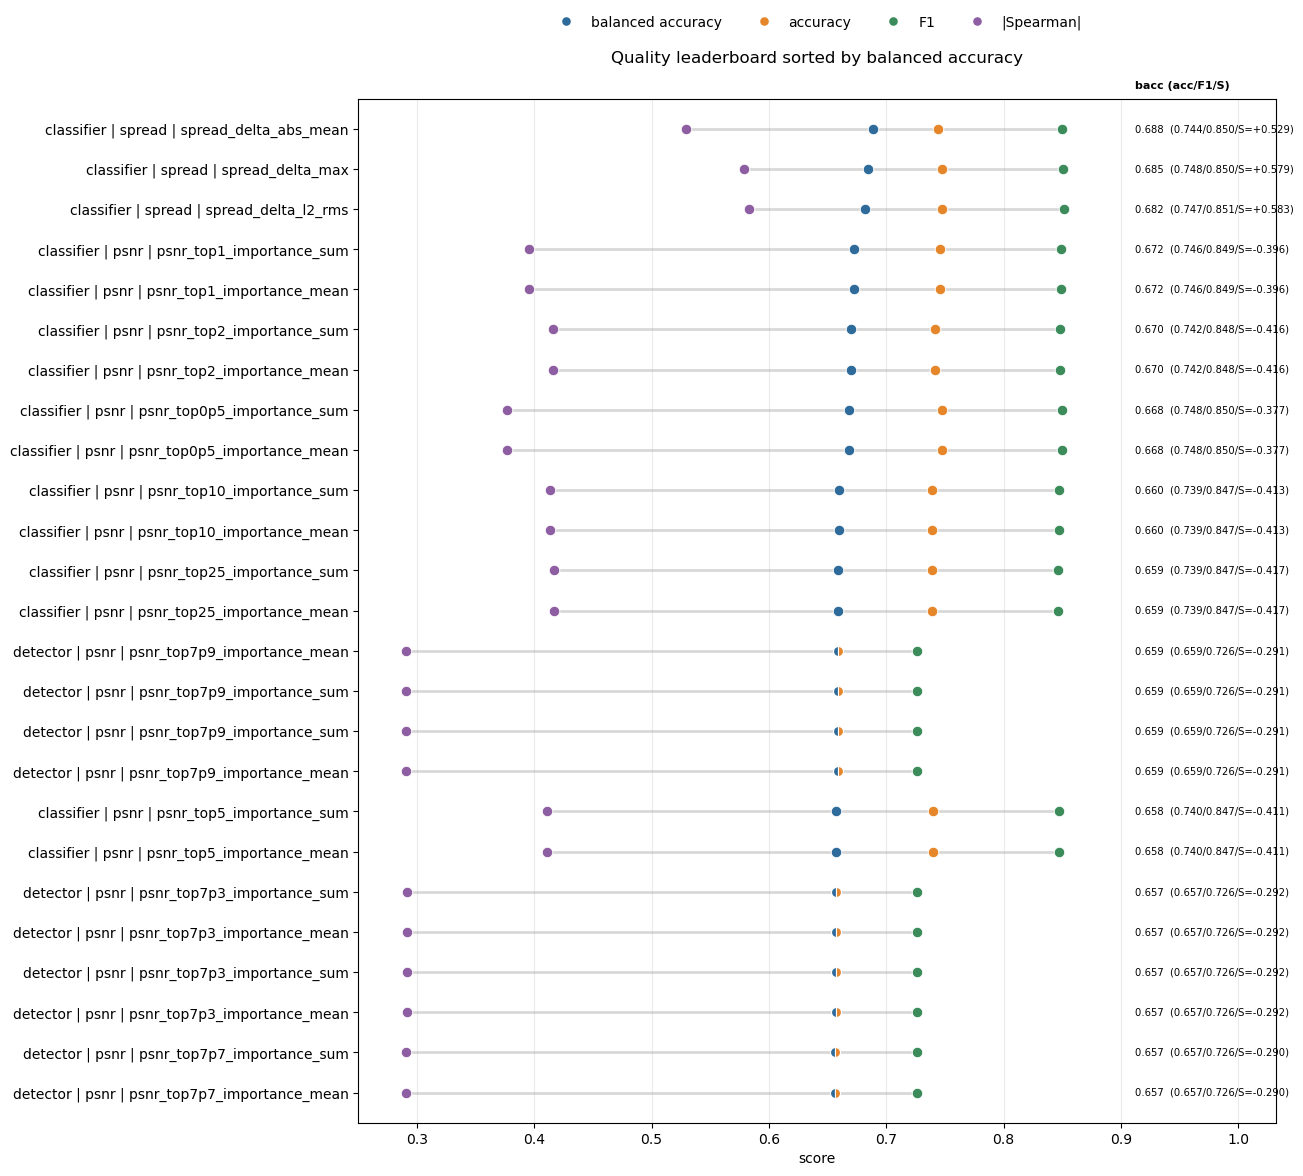

In [7]:
fig = plot_quality_metric_triplets(quality, regression, top_n=25)
fig.savefig(roots.comparison_output / "all_metrics_quality_triplets.png", dpi=160, bbox_inches="tight")
fig

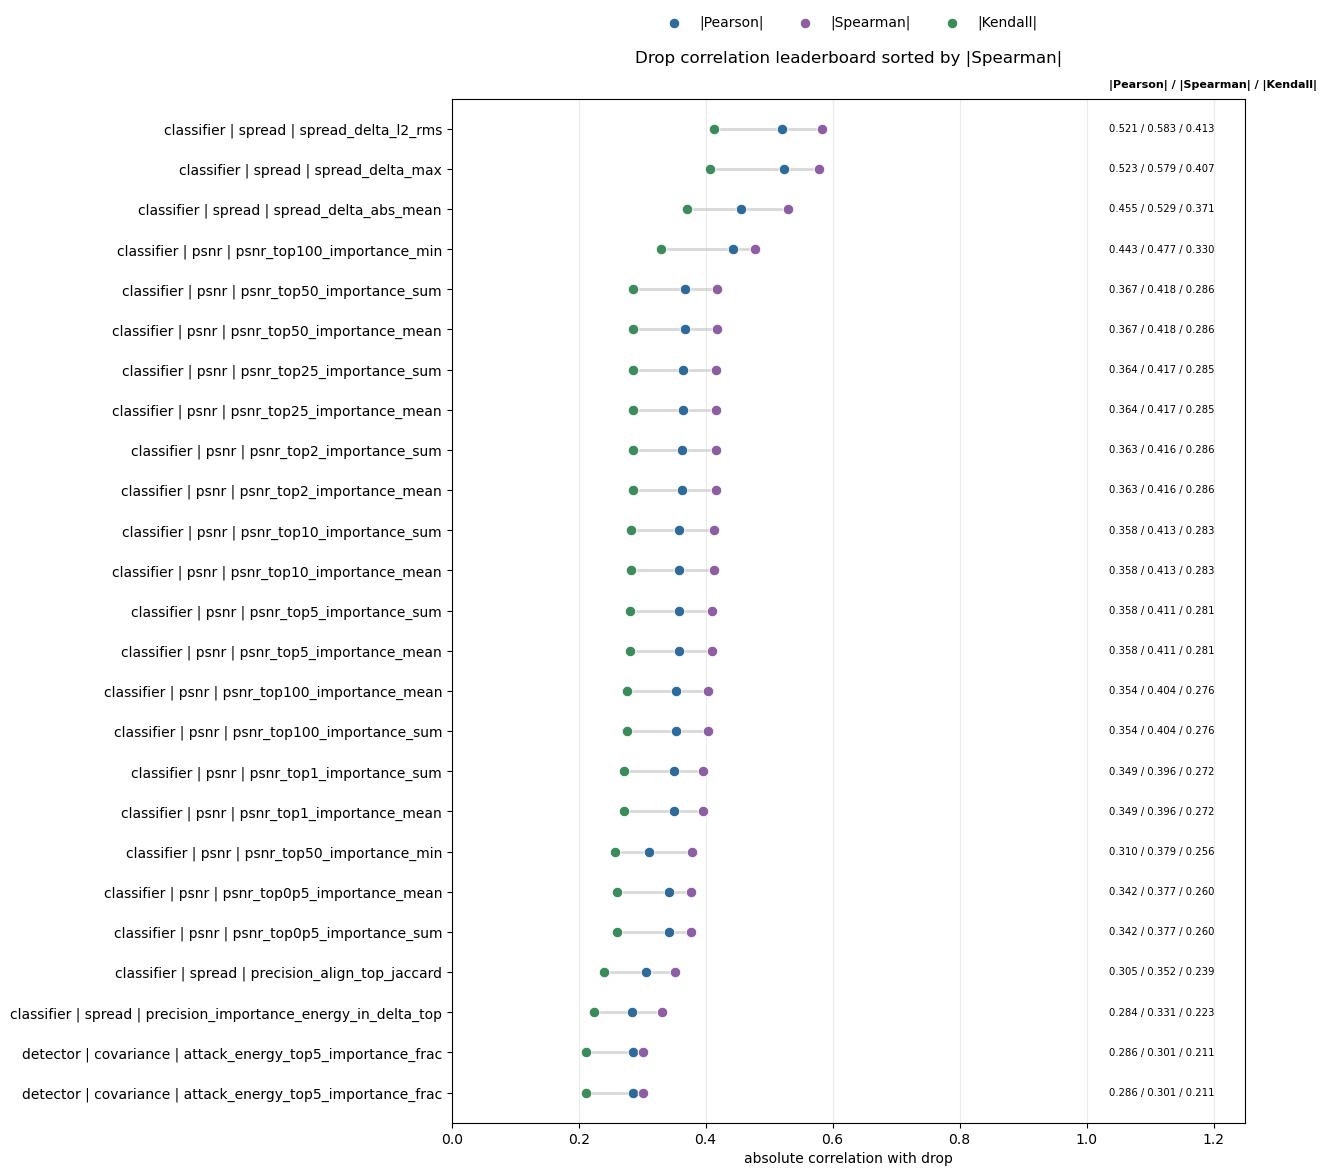

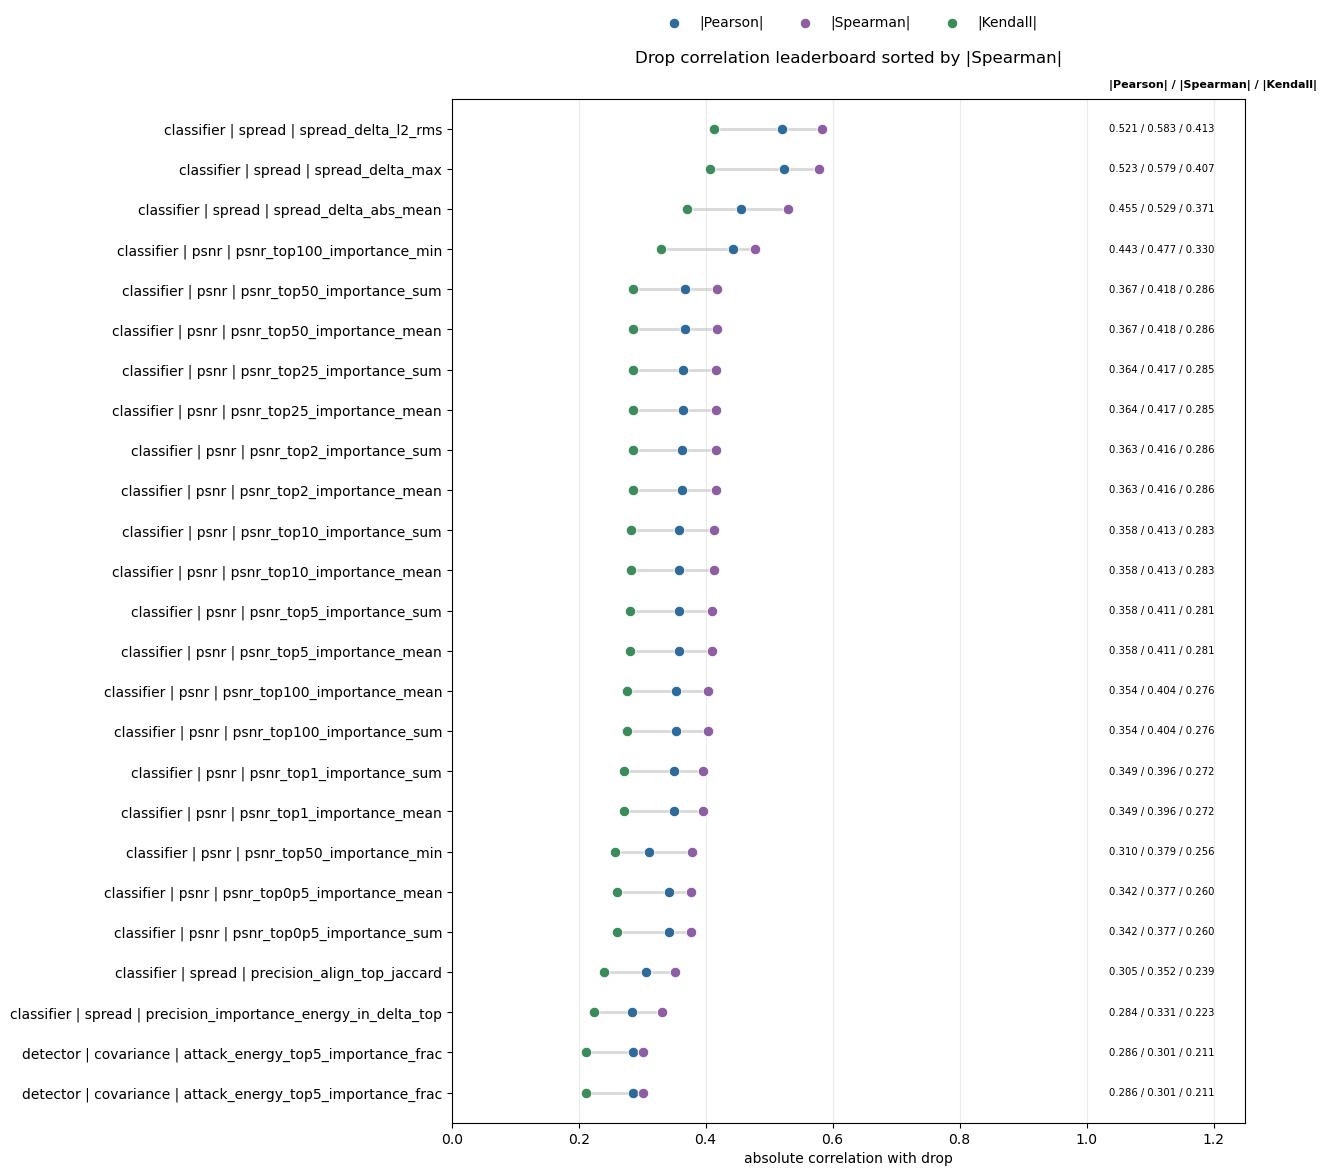

In [8]:
fig = plot_correlation_metric_triplets(regression, top_n=25)
fig.savefig(roots.comparison_output / "all_metrics_correlation_triplets.png", dpi=160, bbox_inches="tight")
fig

In [9]:
quality = sanitize_quality_table(quality)
side_by_side_quality = (
    quality.assign(score=quality["best_balanced_accuracy"])
    .sort_values(["source", "score", "roc_auc"], ascending=[True, False, False], na_position="last")
)
side_by_side_regression = regression.sort_values(["source", "main_score"], ascending=[True, False], na_position="last")

display(side_by_side_quality.head(80))
display(side_by_side_regression.head(80))

,source,experiment,table,metric,roc_auc,best_f1,best_precision,best_recall,best_balanced_accuracy,best_accuracy,...,cache_file,figure_path,raw_roc_auc,top_percent,aggregate,cov_method,sigma,cov_group,roc_auc_effective,score
0,classifier,spread_vs_precision,quality,spread_delta_abs_mean,0.732230,0.850070,0.744819,0.989963,0.688276,0.743967,...,/Users/ashentide/PycharmProjects/PatchSuccessR...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.688276
1,classifier,spread_vs_precision,quality,spread_delta_max,0.743566,0.850203,0.752880,0.976424,0.684508,0.747732,...,/Users/ashentide/PycharmProjects/PatchSuccessR...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.684508
2,classifier,spread_vs_precision,quality,spread_delta_l2_rms,0.740262,0.851214,0.748715,0.986228,0.681676,0.747219,...,/Users/ashentide/PycharmProjects/PatchSuccessR...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.681676
3,classifier,psnr,quality,psnr_top1_importance_sum,0.703432,0.848658,0.753944,0.970588,0.672146,0.746192,...,/Users/ashentide/PycharmProjects/PatchSuccessR...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.672146
4,classifier,psnr,quality,psnr_top1_importance_mean,0.703432,0.848658,0.753944,0.970588,0.672146,0.746192,...,/Users/ashentide/PycharmProjects/PatchSuccessR...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.672146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,detector,psnr,quality,psnr_top8p5_importance_sum,0.303215,0.726505,0.628530,0.860667,0.655685,0.655685,...,/Users/ashentide/PycharmProjects/PatchSuccessR...,NaN,NaN,8.5,sum,NaN,NaN,NaN,NaN,0.655685
43,detector,psnr,quality,psnr_top8p5_importance_mean,0.303215,0.726505,0.628530,0.860667,0.655685,0.655685,...,/Users/ashentide/PycharmProjects/PatchSuccessR...,NaN,NaN,8.5,mean,NaN,NaN,NaN,NaN,0.655685
44,detector,psnr,quality,psnr_top8p5_importance_sum,0.303215,0.726505,0.628530,0.860667,0.655685,0.655685,...,/Users/ashentide/PycharmProjects/PatchSuccessR...,NaN,0.303215,8.5,sum,NaN,NaN,NaN,NaN,0.655685
45,detector,psnr,quality,psnr_top8p5_importance_mean,0.303215,0.726505,0.628530,0.860667,0.655685,0.655685,...,/Users/ashentide/PycharmProjects/PatchSuccessR...,NaN,0.303215,8.5,mean,NaN,NaN,NaN,NaN,0.655685


,source,experiment,table,metric,n,coverage,pearson,spearman,kendall,abs_pearson,...,mutual_info_norm,calibrated_error_score,top_percent,aggregate,cov_method,threshold_id,threshold_kind,threshold_label,threshold,cov_group
0,classifier,spread_vs_precision,regression,spread_delta_l2_rms,5843,1.0,0.520543,0.582729,0.412929,0.520543,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,classifier,spread_vs_precision,regression,spread_delta_max,5843,1.0,0.523179,0.578696,0.407123,0.523179,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,classifier,spread_vs_precision,regression,spread_delta_abs_mean,5843,1.0,0.455276,0.529228,0.370960,0.455276,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,classifier,psnr,regression,psnr_top100_importance_min,5843,1.0,-0.443024,-0.477444,-0.330089,0.443024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,classifier,psnr,regression,psnr_top50_importance_sum,5843,1.0,-0.366723,-0.417650,-0.286173,0.366723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47,detector,covariance,regression,attack_energy_top10_0p1bin_linear_frac,1999,1.0,0.283893,0.299827,0.210225,0.283893,...,0.653435,0.510502,NaN,NaN,full_ig_32,18.0,sigma,mean+1sigma,0.176795,low
48,detector,covariance,regression,attack_energy_top10_0p1bin_linear_frac,1999,1.0,0.284044,0.299815,0.210228,0.284044,...,0.686297,0.510514,NaN,NaN,full_ig_32,21.0,sigma,mean+1.5sigma,0.259707,low
49,detector,covariance,regression,attack_energy_top10_0p1bin_linear_frac,1999,1.0,0.284201,0.299771,0.210202,0.284201,...,0.728096,0.510526,NaN,NaN,full_ig_32,25.0,sigma,mean+2.5sigma,0.425532,low
50,detector,covariance,regression,attack_energy_top10_0p1bin_linear_frac,1999,1.0,0.283809,0.299771,0.210129,0.283809,...,0.664780,0.510496,NaN,NaN,full_ig_32,15.0,sigma,mean+0.75sigma,0.135338,low


In [10]:
quality = sanitize_quality_table(quality)
side_by_side_quality = sanitize_quality_table(side_by_side_quality)

save_tables(
    {
        "quality": quality,
        "regression": regression,
        "side_by_side_quality": side_by_side_quality,
        "side_by_side_regression": side_by_side_regression,
    },
    roots.comparison_output,
    prefix="all_metrics",
)
print("saved to:", roots.comparison_output)
print("saved quality rows:", quality.shape)


saved to: /Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs
saved quality rows: (7632, 33)
